# ЗПАД | Лабораторна робота № 3
## Тема: Візуалізація даних

# Частина: 1

**Виконала:** Городиська Анна, група ФБ-44


### 1: Імпорт бібліотек.
Спочатку підключаємо все необхідне для роботи з датасетом. seaborn допоможе зробити графіки красивими і багатовимірними.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")

# Завантаження датасету
df = pd.read_csv('league_of_legends_professional_matches.csv')

# Перевірка розміру та перших рядків
print(f"Розмір датасету: {df.shape}")
df.head()

Розмір датасету: (5989, 78)


,golId,game,event1,event2,event3,event4,event5,event6,event7,event8,...,redMidGP,redMidWR,redMidKDA,redAdcGP,redAdcWR,redAdcKDA,redSupportGP,redSupportWR,redSupportKDA,result
0,36864,ESPORTSTMNT02_2556988,RED: first_blood,BLUE: dragon,BLUE: herald,BLUE: dragon,BLUE: first_tower_top,RED: first_tower_bot,BLUE: herald,RED: first_tower_mid,...,5,0.20,4.00,0,0.0,0.00,0,0.0,0.0,1
1,36865,ESPORTSTMNT05_2520933,RED: first_blood,RED: herald,BLUE: dragon,RED: first_tower_top,RED: second_tower_top,RED: first_tower_bot,RED: dragon,RED: herald,...,4,0.25,3.55,10,0.4,4.07,2,0.5,5.4,0
2,36866,ESPORTSTMNT02_2557390,RED: first_blood,BLUE: herald,RED: dragon,RED: first_tower_bot,BLUE: herald,BLUE: first_tower_mid,RED: dragon,BLUE: first_tower_top,...,1,0.00,20.00,0,0.0,0.00,4,1.0,2.8,0
3,36867,ESPORTSTMNT02_2557426,RED: dragon,BLUE: first_blood,RED: herald,RED: dragon,RED: herald,BLUE: first_tower_bot,RED: first_tower_mid,BLUE: dragon,...,5,0.20,4.00,5,0.6,9.12,0,0.0,0.0,0
4,36868,ESPORTSTMNT02_2557463,RED: first_blood,BLUE: dragon,BLUE: herald,BLUE: dragon,BLUE: herald,BLUE: first_tower_mid,RED: dragon,RED: first_tower_bot,...,5,0.00,2.35,2,0.0,24.00,0,0.0,0.0,0


### 2: Data Cleaning.
Професійні дані часто мають пропуски в колонках з дрібною статистикою 
(наприклад, шкода по вежах або кількість встановлених тотемів) через специфіку роботи API турнірів. Щоб цих пропусків не було я виконала data cleaning.

In [21]:
# Перевірка наявності пропущених значень
print("Пропуски до очищення:\n", df.isnull().sum().sort_values(ascending=False).head(10))

# 1. Видаляємо колонки, де більше 50% даних відсутні (бо вони не інформативні)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

# 2. Заповнюємо пропуски в числових колонках медіаною
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 3. Заповнюємо пропуски в категоріальних колонках найчастішим значенням
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nПропуски після очищення: ", df.isnull().sum().max()) 

Пропуски до очищення:
 event45    5988
event43    5987
event44    5987
event42    5986
event41    5983
event40    5980
event39    5978
event38    5961
event37    5947
event36    5930
dtype: int64

Пропуски після очищення:  0


### 3:Графік залежності одного integer/real атрибута від іншого
Подивимося, чи є пряма залежність між KDA мідлейнера та його загальним відсотком перемог.

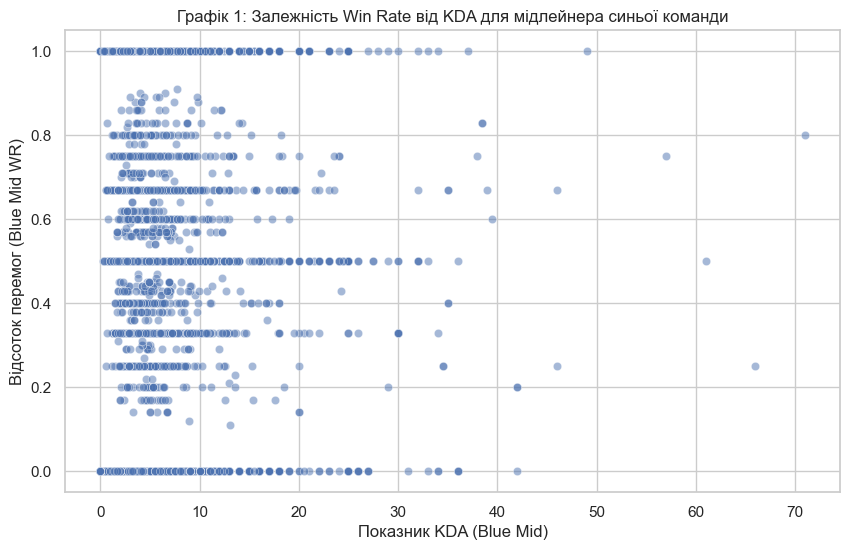

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='blueMidKDA', y='blueMidWR', alpha=0.5, color='b')
plt.title('Графік 1: Залежність Win Rate від KDA для мідлейнера синьої команди')
plt.xlabel('Показник KDA (Blue Mid)')
plt.ylabel('Відсоток перемог (Blue Mid WR)')
plt.show()

### 4: Гістограма розподілу атрибута на 5 діапазонів
Згідно з вимогами лабораторної роботи, наступний графік демонструє розподіл одного з числових атрибутів, розбитий рівно на 5 заданих діапазонів.

Для аналізу обрано показник KDA стрільця синьої команди (`blueADCKDA`). Гістограма дозволяє наочно оцінити щільність розподілу результативності гравців на цій позиції:
* Чітко видно центральну тенденцію (діапазон, у якому знаходиться абсолютна більшість гравців).

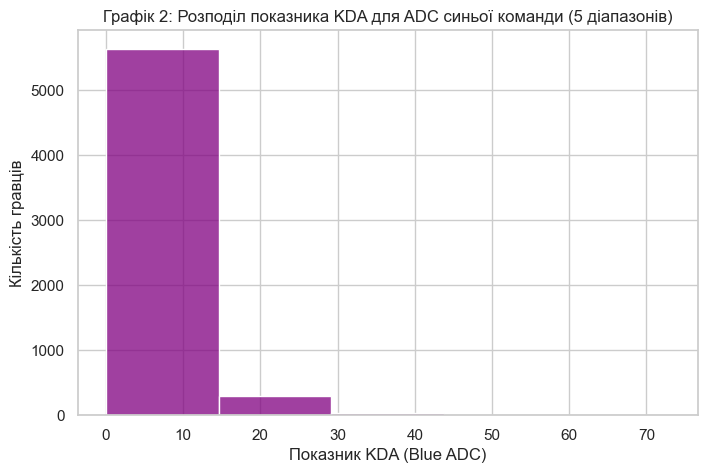

In [23]:
# Конвертуємо секунди у хвилини для зручності
plt.figure(figsize=(8, 5))
sns.histplot(df['blueADCKDA'], bins=5, color='purple', kde=False)
plt.title('Графік 2: Розподіл показника KDA для ADC синьої команди (5 діапазонів)')
plt.xlabel('Показник KDA (Blue ADC)')
plt.ylabel('Кількість гравців')
plt.show()

### 5: Багатовимірні візуалізації
Згідно з вимогами лабораторної роботи, наступні графіки побудовані з використанням підходів до ефективної візуалізації 
багатовимірних даних (на основі прикладів зі статті на Medium). 

Щоб показати більше ніж дві змінні на плоскому екрані,я використала додаткові візуальні канали: колір та розмір точок .

* **Графік 3 (4D Scatterplot):** Відображає відразу 4 виміри даних про лісника синьої команди (Blue Jungle):
  1. **Вісь X:** Показник KDA.
  2. **Вісь Y:** Загальний відсоток перемог (Win Rate).
  3. **Колір (Hue):** Фінальний результат конкретного матчу (перемога чи поразка).
  4. **Розмір точки (Size):** Кількість зіграних ігор (чим більша точка, тим досвідченіший гравець).
  Цей графік дозволяє побачити складні патерни, наприклад, чи частіше перемагають досвідчені лісники з високим KDA.

* **Графік 4 (Pairplot):** Комплексна матриця діаграм розсіювання. Вона дозволяє одночасно оцінити попарні кореляції між KDA трьох різних позицій (Топ, Ліс, Мід), при цьому кольором виділено результат гри. 

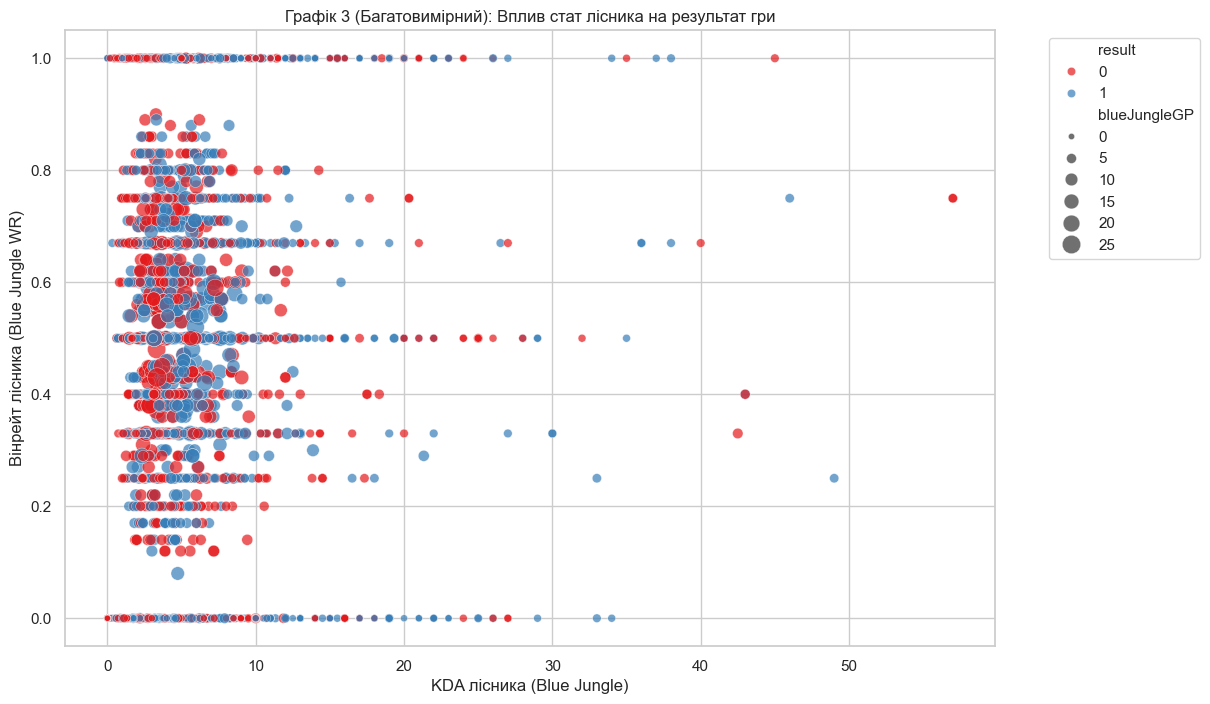

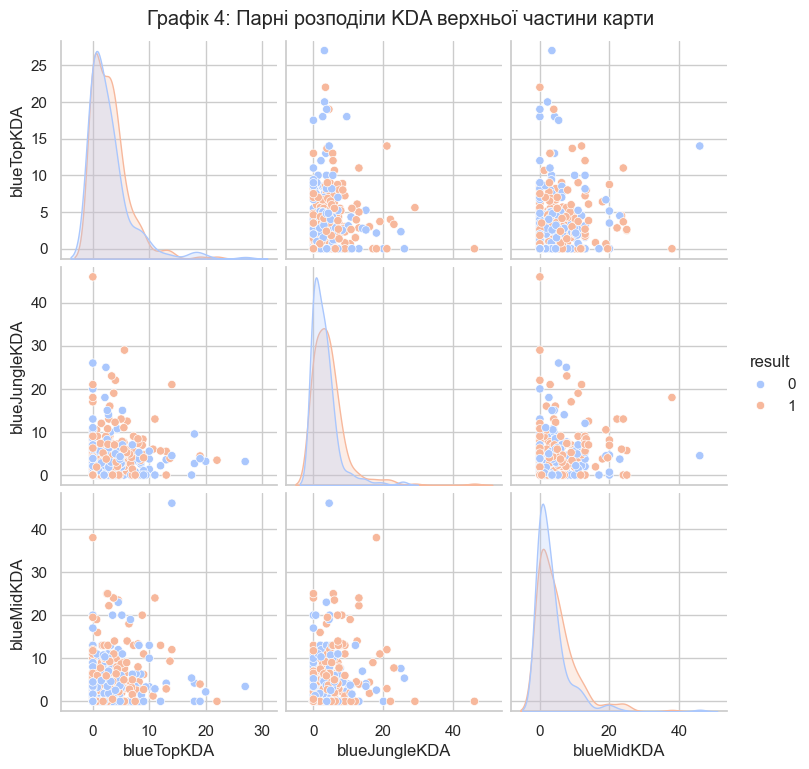

In [24]:
# Графік 3 (4D Scatterplot)
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df, 
    x='blueJungleKDA', 
    y='blueJungleWR', 
    hue='result', # Колір: Перемога чи поразка в цьому матчі
    size='blueJungleGP', # Розмір: Кількість зіграних ігор лісником
    sizes=(20, 200),
    palette='Set1',
    alpha=0.7
)
plt.title('Графік 3 (Багатовимірний): Вплив стат лісника на результат гри')
plt.xlabel('KDA лісника (Blue Jungle)')
plt.ylabel('Вінрейт лісника (Blue Jungle WR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Графік 4: Pairplot для комплексного огляду топ-лінії та лісу
metrics = ['blueTopKDA', 'blueJungleKDA', 'blueMidKDA']
# Беремо вибірку з 500 рядків, щоб графік побудувався швидко
sns.pairplot(df[metrics + ['result']].sample(min(500, len(df))), hue='result', palette='coolwarm')
plt.suptitle('Графік 4: Парні розподіли KDA верхньої частини карти', y=1.02)
plt.show()

### 6: Комплексний огляд додаткових ігрових метрик (Subplots)
Для більш глибокого розуміння набору даних побудовано три додаткові графіки, об'єднані в одну фігуру за допомогою `plt.subplots`.
* **Графік 5 (Barplot):** Демонструє загальний розподіл результатів матчів (кількість перемог та поразок) у датасеті.
* **Графік 6 (Boxplot):** Візуалізує розподіл KDA ворожого стрільця (Red ADC) залежно від фінального результату гри. 
* **Графік 7 (Lineplot):** Відображає синхронність зміни KDA стрільця (Blue ADC) та його сапорта (Blue Support) на вибірці з перших 100 матчів. 

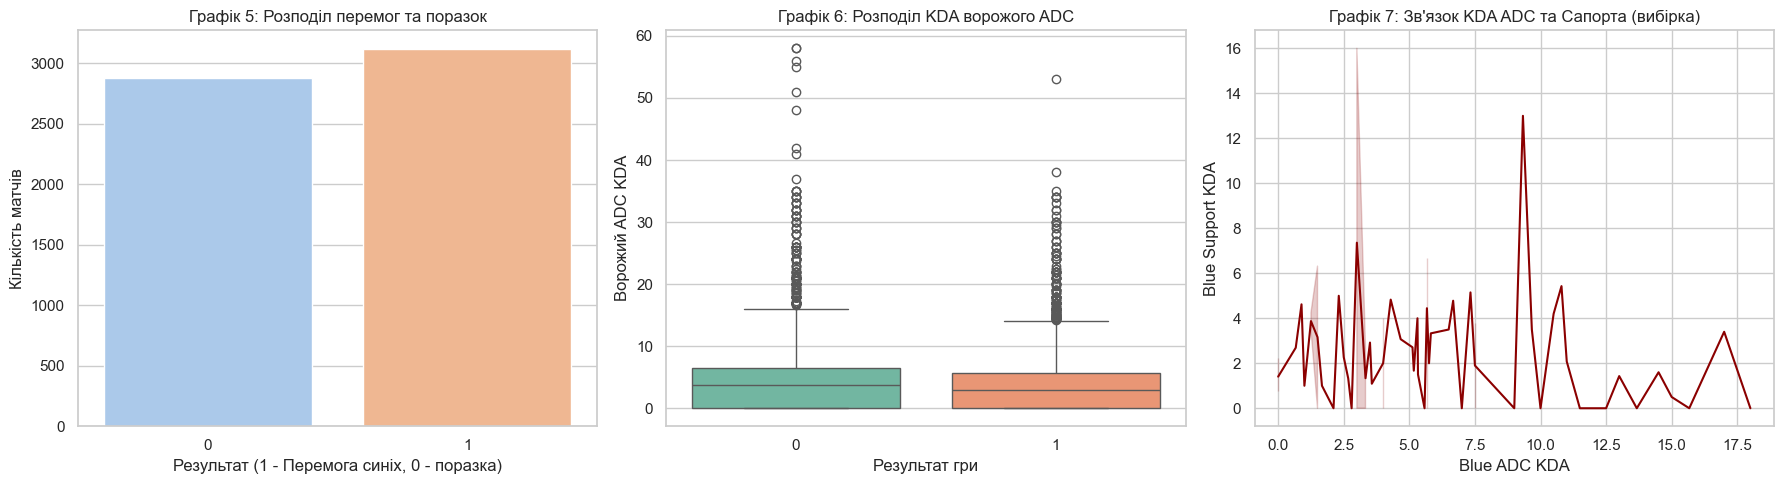

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Графік 5: Barplot (Категоріальний) - Розподіл результатів матчів
sns.countplot(data=df, x='result', hue='result', legend=False, ax=axes[0], palette='pastel')
axes[0].set_title('Графік 5: Розподіл перемог та поразок')
axes[0].set_xlabel('Результат (1 - Перемога синіх, 0 - поразка)')
axes[0].set_ylabel('Кількість матчів')

# Графік 6: Boxplot (Розподіл з викидами) - KDA ворожого ADC відносно результату
sns.boxplot(data=df, x='result', y='redAdcKDA', hue='result', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('Графік 6: Розподіл KDA ворожого ADC')
axes[1].set_xlabel('Результат гри')
axes[1].set_ylabel('Ворожий ADC KDA')

# Графік 7: Lineplot - Як KDA сапорта змінюється разом із KDA ADC (для перших 100 записів)
sns.lineplot(data=df.head(100), x='blueADCKDA', y='blueSupportKDA', ax=axes[2], color='darkred')
axes[2].set_title('Графік 7: Зв\'язок KDA ADC та Сапорта (вибірка)')
axes[2].set_xlabel('Blue ADC KDA')
axes[2].set_ylabel('Blue Support KDA')

plt.tight_layout()
plt.show()